In [33]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [34]:
import os
import sys
import torch
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

device = torch.device('cuda')

# include parent dir in python path
sys.path.append('/media/carsen/ssd1/approxineuro/notebooks')

In [35]:
from utils import data
mouse_id = 6
depth_separable = True
pool = True
clamp = True
use_30k = False # use all data recorded (>30k) or only 30k, performance will decrease if use only 30k.
data_path = '../data'

# change path to your own dm11 path
img_root = '/home/carsen/dm11_pachitariu/data/STIM/'
# weight_path = '/home/carsen/dm11/Farah/EncodingModel/weights'
weight_path = '../weights/'

In [48]:
weight_path = '../weights/'

In [36]:
# load images
img = data.load_images(img_root, file=os.path.join(img_root, data.img_file_name[mouse_id]))
nimg, Ly, Lx = img.shape
print('img: ', img.shape, img.min(), img.max(), img.dtype)

raw image shape:  (68032, 66, 264)
cropped image shape:  (68032, 66, 130)
image mean:  126.71216
image std:  61.42324
img:  (68032, 66, 130) -2.062935 2.088588 float32


In [37]:
# load neurons
fname = '%s_nat60k_%s.npz'%(data.db[mouse_id]['mname'], data.db[mouse_id]['datexp'])
spks, istim_train, istim_test, xpos, ypos, spks_rep_all = data.load_neurons(file_path = os.path.join(data_path, fname), mouse_id = mouse_id, fixtrain=use_30k)
n_stim, n_neurons = spks.shape
print('spks: ', spks.shape, spks.min(), spks.max())
print('spks_rep_all: ', len(spks_rep_all), spks_rep_all[0].shape)
print('istim_train: ', istim_train.shape, istim_train.min(), istim_train.max())
print('istim_test: ', istim_test.shape, istim_test.min(), istim_test.max())


loading activities from ../data/FX40_nat60k_2024_10_29.npz
spks:  (29500, 4261) nan nan
spks_rep_all:  500 (10, 4261)
istim_train:  (29500,) 532 30031
istim_test:  (500,) 32 531


In [38]:
# split train and validation set
itrain, ival = data.split_train_val(istim_train, train_frac=0.9)
print('itrain: ', itrain.shape, itrain.min(), itrain.max())
print('ival: ', ival.shape, ival.min(), ival.max())


splitting training and validation set...
there is currently no randomness in this function now, please make sure the istim_train is in random order!
itrain:  (26550,)
ival:  (2950,)
itrain:  (26550,) 1 29499
ival:  (2950,) 0 29490


In [39]:
spks, spks_rep_all = data.normalize_spks(spks, spks_rep_all, itrain)


normalizing neural data...


In [40]:
ineur = np.arange(0, n_neurons) #np.arange(0, n_neurons, 5)
spks_train = torch.from_numpy(spks[itrain][:,ineur])
spks_val = torch.from_numpy(spks[ival][:,ineur]) 

print('spks_train: ', spks_train.shape, spks_train.min(), spks_train.max())
print('spks_val: ', spks_val.shape, spks_val.min(), spks_val.max())

img_train = torch.from_numpy(img[istim_train][itrain]).to(device).unsqueeze(1) # change :130 to 25:100 
img_val = torch.from_numpy(img[istim_train][ival]).to(device).unsqueeze(1)
img_test = torch.from_numpy(img[istim_test]).to(device).unsqueeze(1)

print('img_train: ', img_train.shape, img_train.min(), img_train.max())
print('img_val: ', img_val.shape, img_val.min(), img_val.max())
print('img_test: ', img_test.shape, img_test.min(), img_test.max())

input_Ly, input_Lx = img_train.shape[-2:]

spks_train:  torch.Size([26550, 4261]) tensor(nan) tensor(nan)
spks_val:  torch.Size([2950, 4261]) tensor(nan) tensor(nan)
img_train:  torch.Size([26550, 1, 66, 130]) tensor(-2.0629, device='cuda:0') tensor(2.0886, device='cuda:0')
img_val:  torch.Size([2950, 1, 66, 130]) tensor(-2.0629, device='cuda:0') tensor(2.0886, device='cuda:0')
img_test:  torch.Size([500, 1, 66, 130]) tensor(-2.0629, device='cuda:0') tensor(2.0886, device='cuda:0')


In [44]:
train_real_responses = torch.ones_like(spks_train)
val_real_responses = torch.ones_like(spks_val)
# set nans to zero
train_real_responses[torch.isnan(spks_train)] = 0
val_real_responses[torch.isnan(spks_val)] = 0
spks_train[torch.isnan(spks_train)] = 0
spks_val[torch.isnan(spks_val)] = 0

In [45]:
# build model
from utils import model_builder
nlayers = 2
nconv1 = 16
nconv2 = 320
model, in_channels = model_builder.build_model(NN=len(ineur), n_layers=nlayers, n_conv=nconv1, n_conv_mid=nconv2, pool=pool, depth_separable=depth_separable)
model_name = model_builder.create_model_name(data.mouse_names[mouse_id], data.exp_date[mouse_id], n_layers=nlayers, in_channels=in_channels, clamp=clamp, suffix='')
# weight_path = './checkpoints/'
model_path = os.path.join(weight_path, model_name)
model = model.to(device)

input shape of readout:  (320, 33, 65)
model name:  FX40_102924_2layer_16_320_clamp_sensorium_depthsep_pool.pt


In [47]:
# train model
from utils import model_trainer
if not os.path.exists(model_path):
    best_state_dict = model_trainer.monkey_train(model, spks_train, train_real_responses, spks_val, val_real_responses, img_train, img_val, device=device)
    torch.save(best_state_dict, model_path)
    print('model saved', model_path)
model.load_state_dict(torch.load(model_path))
print('loaded model', model_path)

0.001
epoch 0, train_loss = 0.0087, val_loss = 0.0086, varexp_val = 0.0248, time 45.74s
epoch 1, train_loss = 0.0085, val_loss = 0.0086, varexp_val = 0.0340, time 90.58s
epoch 2, train_loss = 0.0084, val_loss = 0.0086, varexp_val = 0.0392, time 134.45s
epoch 3, train_loss = 0.0084, val_loss = 0.0085, varexp_val = 0.0431, time 178.99s
epoch 4, train_loss = 0.0084, val_loss = 0.0085, varexp_val = 0.0452, time 224.63s
epoch 5, train_loss = 0.0083, val_loss = 0.0085, varexp_val = 0.0480, time 270.35s
epoch 6, train_loss = 0.0083, val_loss = 0.0085, varexp_val = 0.0499, time 316.92s
epoch 7, train_loss = 0.0083, val_loss = 0.0085, varexp_val = 0.0508, time 364.18s
epoch 8, train_loss = 0.0083, val_loss = 0.0085, varexp_val = 0.0508, time 411.07s
epoch 9, train_loss = 0.0083, val_loss = 0.0085, varexp_val = 0.0521, time 457.98s
epoch 10, train_loss = 0.0083, val_loss = 0.0085, varexp_val = 0.0542, time 506.54s
epoch 11, train_loss = 0.0083, val_loss = 0.0085, varexp_val = 0.0542, time 554.40

RuntimeError: Parent directory ./checkpoints does not exist.

In [51]:
# test model
from utils import model_trainer
test_pred = model_trainer.test_epoch(model, img_test)
print('test_pred: ', test_pred.shape, test_pred.min(), test_pred.max())

test_pred:  (500, 4261) 0.0107931495 6.684019


In [52]:
from utils import metrics
test_fev, test_feve = metrics.feve_nan(spks_rep_all, test_pred)
print('FEVE (test): ', np.mean(test_feve))

threshold = 0.15
print(f'filtering neurons with FEV > {threshold}')
valid_idxes = np.where(test_fev > threshold)[0]
print(f'valid neurons: {len(valid_idxes)} / {len(test_fev)}')
print(f'FEVE (test): {np.mean(test_feve[test_fev > threshold])}')

FEVE (test):  -0.06752182
filtering neurons with FEV > 0.15
valid neurons: 1227 / 4261
FEVE (test): 0.6520859003067017


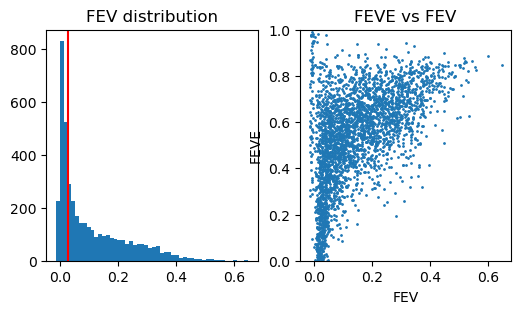

In [57]:
fig, ax = plt.subplots(1, 2, figsize=(6, 3))
ax[0].hist(test_fev, bins=50)
ax[0].axvline(0.025, color='r')
ax[0].set_title('FEV distribution')
ax[1].scatter(test_fev, test_feve, s=1)
ax[1].set_title('FEVE vs FEV')
ax[1].set_xlabel('FEV')
ax[1].set_ylabel('FEVE')
ax[1].set_ylim(0, 1)
plt.show()

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(3, 3))

In [ ]:
spks_rep_all[0].shape

(10, 2746)

# retinotopy

In [66]:
from utils.model_utils import weight_bandwidth
x_pixel_ratio = 0.75
y_pixel_ratio = 0.5
Wx = model.readout.Wx.cpu().detach().numpy().squeeze()
Wy = model.readout.Wy.cpu().detach().numpy().squeeze()
NN = Wx.shape[0]
bandwidth_Wx = np.zeros(NN)
bandwidth_Wy = np.zeros(NN)
centerpos_Wx = np.zeros(NN)
centerpos_Wy = np.zeros(NN)
for i in range(NN):
    bandwidth_Wx[i], centerpos_Wx[i] = weight_bandwidth(Wx[i, :], return_peak=True)
    bandwidth_Wy[i], centerpos_Wy[i] = weight_bandwidth(Wy[i, :], return_peak=True)
xpos_model = np.argmax(Wx.squeeze(), axis=1) 
ypos_model = np.argmax(Wy.squeeze(), axis=1) 
xpos_visual = centerpos_Wx*2*(270/264) - 135 # 0 is at the center, so it should be 135 pixels
ypos_visual = centerpos_Wy*2*(65/66) - 32.5 # vertical visual range is 65, so it sould be (66/65) pixels per degree
if mouse_id == 5: xpos_visual += (46*270/264) # xrange of mouse 6 is 46-176
xpos = xpos / x_pixel_ratio
ypos = ypos / y_pixel_ratio
if mouse_id == 1:
    idx_up = np.where(xpos>325/ x_pixel_ratio)[0]
    idx_down = np.where(xpos<=325/ x_pixel_ratio)[0]
    ymax = ypos[idx_up].max()
    xmax, xmin = xpos[idx_up].max(), xpos[idx_up].min()
    ypos[idx_up] = ymax - ypos[idx_up] +300 # + ymax

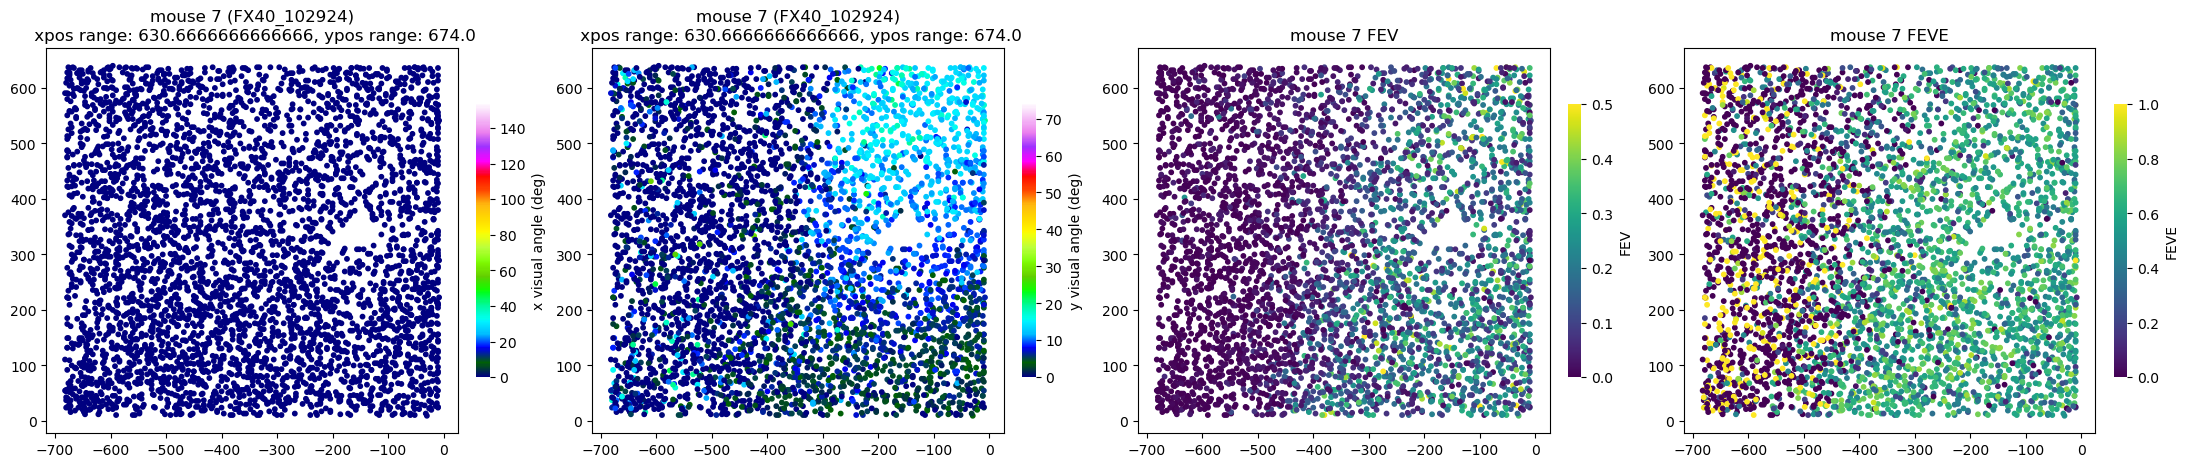

In [79]:
fig, ax = plt.subplots(1, 4, figsize=(27, 5))
sc = ax[0].scatter(-ypos, xpos, c=xpos_visual, s=10, cmap='gist_ncar', vmin=0, vmax=(270 * (50/88)))
cbar = fig.colorbar(sc, ax=ax[0], fraction=0.03, pad=0.04)
cbar.outline.set_visible(False)
cbar.set_label('x visual angle (deg)')
ax[0].set_title(f'mouse {mouse_id+1} ({data.mouse_names[mouse_id]}_{data.exp_date[mouse_id]})\n xpos range: {np.max(xpos)-np.min(xpos)}, ypos range: {np.max(ypos)-np.min(ypos)}', loc='center')
ax[0].set_aspect('equal', adjustable='box')
# ax.set_axis_off()
# fig.savefig(f'./outputs/{data.mouse_names[mouse_id]}_{data.exp_date[mouse_id]}_xpos_visual.png', dpi=300, bbox_inches='tight')
# plt.close(fig)
sc = ax[1].scatter(-ypos, xpos, c=ypos_visual, s=10, cmap='gist_ncar', vmin=0, vmax=65 * (25/22))
cbar = fig.colorbar(sc, ax=ax[1], fraction=0.03, pad=0.04)
cbar.outline.set_visible(False)
cbar.set_label('y visual angle (deg)')
ax[1].set_title(f'mouse {mouse_id+1} ({data.mouse_names[mouse_id]}_{data.exp_date[mouse_id]})\n xpos range: {np.max(xpos)-np.min(xpos)}, ypos range: {np.max(ypos)-np.min(ypos)}', loc='center')
ax[1].set_aspect('equal', adjustable='box')

sc = ax[2].scatter(-ypos, xpos, c=test_fev, s=10, cmap='viridis', vmin=0, vmax=0.5)
cbar = fig.colorbar(sc, ax=ax[2], fraction=0.03, pad=0.04)
cbar.outline.set_visible(False)
cbar.set_label('FEV')
ax[2].set_title(f'mouse {mouse_id+1} FEV', loc='center')
ax[2].set_aspect('equal', adjustable='box')

sc = ax[3].scatter(-ypos, xpos, c=test_feve, s=10, cmap='viridis', vmin=0, vmax=1)
cbar = fig.colorbar(sc, ax=ax[3], fraction=0.03, pad=0.04)
cbar.outline.set_visible(False)
cbar.set_label('FEVE')
ax[3].set_title(f'mouse {mouse_id+1} FEVE', loc='center')
ax[3].set_aspect('equal', adjustable='box')



In [64]:
# $

(4261, 1, 65)


# visualize model

In [58]:
model

Encoder(
  (core): Core(
    (features): Sequential(
      (layer0): Sequential(
        (conv): Conv2d(1, 16, kernel_size=(25, 25), stride=(1, 1), padding=(12, 12), bias=False)
        (norm): BatchNorm2d(16, eps=1e-05, momentum=0.9, affine=True, track_running_stats=True)
        (activation): ELU(alpha=1.0)
        (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      )
      (layer1): Sequential(
        (ds_conv): Sequential(
          (in_depth_conv): Conv2d(16, 320, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (spatial_conv): Conv2d(320, 320, kernel_size=(9, 9), stride=(1, 1), padding=(4, 4), groups=320, bias=False)
          (out_depth_conv): Conv2d(320, 320, kernel_size=(1, 1), stride=(1, 1), bias=False)
        )
        (norm): BatchNorm2d(320, eps=1e-05, momentum=0.9, affine=True, track_running_stats=True)
        (activation): ELU(alpha=1.0)
      )
    )
  )
  (readout): Readout(
    (activation): ELU(alpha=1.0)
  )
  (bceloss

conv1_w:  (16, 25, 25) -0.25759962 0.40487835


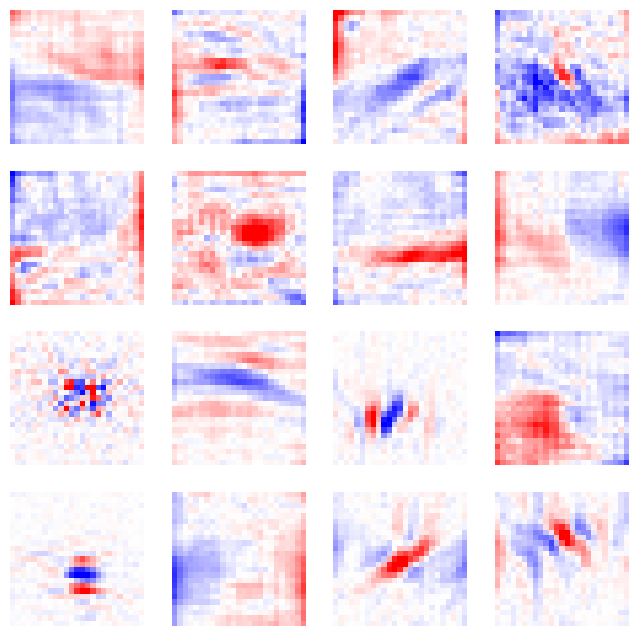

In [62]:
conv1_w = model.core.features.layer0.conv.weight.detach().cpu().numpy().squeeze()
print('conv1_w: ', conv1_w.shape, conv1_w.min(), conv1_w.max())

fig, ax = plt.subplots(4, 4, figsize=(8, 8))
for i in range(16):
    ax[i//4, i%4].imshow(conv1_w[i], cmap='bwr', vmin=-0.2, vmax=0.2)
    ax[i//4, i%4].axis('off')

# multilayers result

In [ ]:
from utils import model_builder
mouse_id = 0
feve_all = np.zeros((6, 4))
for mouse_id in [5]:
    # load image
    img = data.load_images(img_root, file=os.path.join(img_root, img_file_name[mouse_id]))
    nimg, Ly, Lx = img.shape
    # load neurons
    fname = '%s_nat60k_%s.npz'%(db[mouse_id]['mname'], db[mouse_id]['datexp'])
    spks, istim_train, istim_test, xpos, ypos, spks_rep_all = data.load_neurons(file_path = os.path.join(data_path, fname), mouse_id = mouse_id, fixtrain=use_30k)
    n_stim, n_neurons = spks.shape
    itrain, ival = data.split_train_val(istim_train, train_frac=0.9)
    spks, spks_rep_all = data.normalize_spks(spks, spks_rep_all, itrain)
    img_test = torch.from_numpy(img[istim_test]).to(device).unsqueeze(1)

    nlayers = 2
    for nlayers in [1,2,3,4]:
        nconv1 = 192
        nconv2 = 192
        model, in_channels = model_builder.build_model(NN=n_neurons, n_layers=nlayers, n_conv=nconv1, n_conv_mid=nconv2, pool=pool, depth_separable=depth_separable)
        model_name = model_builder.create_model_name(mouse_names[mouse_id], exp_date[mouse_id], n_layers=nlayers, in_channels=in_channels, clamp=clamp)
        # weight_path = os.path.join(server_path, 'weights')
        model_path = os.path.join(weight_path, model_name)

        model.load_state_dict(torch.load(model_path))
        print('loaded model', model_path)
        model = model.to(device)

        test_pred = model_trainer.test_epoch(model, img_test)
        # print('test_pred: ', test_pred.shape, test_pred.min(), test_pred.max())

        from utils import metrics
        test_fev, test_feve = metrics.feve(spks_rep_all, test_pred)
        print('FEVE (test): ', np.mean(test_feve))

        threshold = 0.15
        valid_idxes = np.where(test_fev > threshold)[0]
        print(f'FEVE (test with FEV > {threshold}): {np.mean(test_feve[test_fev > threshold])}')
        feve_all[mouse_id, nlayers-1] = np.mean(test_feve[test_fev > threshold])

raw image shape:  (68000, 66, 264)
cropped image shape:  (68000, 66, 130)
image mean:  126.71192
image std:  61.422768

loading activities from ./data/FX20_nat60k_2023_09_29.npz

splitting training and validation set...
there is currently no randomness in this function now, please make sure the istim_train is in random order!
itrain:  (43081,)
ival:  (4787,)

normalizing neural data...
input shape of readout:  (192, 33, 65)
model name:  FX20_092923_1layer_192_clamp_sensorium_depthsep_pool.pt
loaded model /home/carsen/dm11/Farah/EncodingModel/weights/FX20_092923_1layer_192_clamp_sensorium_depthsep_pool.pt
FEVE (test):  0.42236032193279616
FEVE (test with FEV > 0.15): 0.5543960313758773
input shape of readout:  (192, 33, 65)
model name:  FX20_092923_2layer_192_192_clamp_sensorium_depthsep_pool.pt
loaded model /home/carsen/dm11/Farah/EncodingModel/weights/FX20_092923_2layer_192_192_clamp_sensorium_depthsep_pool.pt
FEVE (test):  0.5131794307767882
FEVE (test with FEV > 0.15): 0.64581477712

In [ ]:
feve_all = np.load('mouse_feve_all.npy')
print(feve_all)

[[0.58268666 0.68740642 0.70879954 0.7109586 ]
 [0.55588335 0.7374543  0.7416724  0.74350303]
 [0.59818822 0.71267503 0.73688674 0.72792023]
 [0.56972641 0.67200828 0.70336568 0.70903373]
 [0.54559141 0.65996075 0.68527335 0.6920405 ]
 [       nan        nan        nan        nan]]


In [ ]:
np.save('mouse_feve_all.npy', feve_all)

In [ ]:
lurz_feve_all = np.load('../sensorium/lurz_feve_all.npy')

[0.57041521 0.69390095 0.71519954 0.71669122]


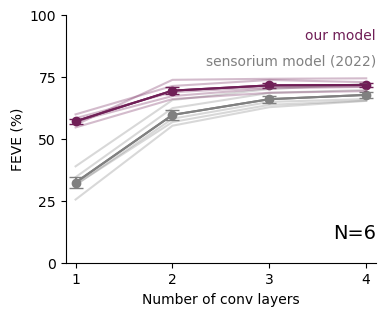

In [ ]:
feve_our_model = feve_all
feve_lurz_model = lurz_feve_all
#  replace nans to 0
feve_our_model = feve_our_model[:5]
feve_lurz_model = feve_lurz_model[:5]
fig, ax = plt.subplots(1, 1, figsize=(4,4))
print(feve_our_model.mean(0))
from scipy.stats import sem
import seaborn as sns
cmap = sns.color_palette('rocket')
nmouse = 5
ax.errorbar(np.arange(4), feve_our_model.mean(0), yerr=sem(feve_our_model, 0), c=cmap[1], capsize=5, label='our model')
ax.errorbar(np.arange(4), feve_lurz_model .mean(0), yerr=sem(feve_lurz_model, 0), c='gray', capsize=5, label='sensorium model (2022)')
ax.plot(np.arange(4), feve_our_model.mean(0), 'o-', c=cmap[1], label='our model')
ax.plot(np.arange(4), feve_lurz_model .mean(0), 'o-', c='gray', label='sensorium model (2022)')
for i in range(nmouse):
    ax.plot(np.arange(4), feve_our_model[i], c=cmap[1], alpha=0.3)
    ax.plot(np.arange(4), feve_lurz_model[i], c='gray', alpha=0.3)
# ax.legend(fontsize=12, loc='lower right')
ax.text(1, 0.9, "our model", transform=ax.transAxes, ha="right", color=cmap[1])
ax.text(1, 0.8, "sensorium model (2022)", transform=ax.transAxes, ha="right", color="gray")
ax.text(1, 0.1, "N=6", transform=ax.transAxes, ha="right", fontsize=14)
ax.set_xlabel('Number of conv layers')
ax.set_ylabel('FEVE (%)')
ax.set_ylim(0, 1)
ax.set_xlim(-0.1, 3.1)
ax.set_xticks([0, 1, 2, 3], [1, 2, 3, 4])
ax.set_yticks(np.arange(0, 1.1, 0.25), labels=[f'{i*100:.0f}' for i in np.arange(0, 1.1, 0.25)])
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.set_aspect(0.8*np.diff(ax.get_xlim())/np.diff(ax.get_ylim()), adjustable='box')